# UAV Flight Path Visualization Tutorial

This tutorial demonstrates how to visualize UAV flight paths and render camera views for 3D scene reconstruction projects.

## Overview

In UAV photogrammetry, drones capture images along planned trajectories to reconstruct 3D models of structures. This tutorial covers:
- Loading and visualizing camera waypoints
- Understanding camera representation in 3D space  
- Rendering views from UAV perspectives
- Creating comprehensive 3D visualizations

## Environment Setup

Import the helper functions and initialize the system with resource monitoring.


In [1]:
from helpers import *

# Initialize with configuration and enable resource monitoring
init("config1.yml", is_for_photo=True)
config = shared['config']

The initialization loads scene configuration and displays CPU/GPU usage monitors to track system performance during rendering operations.


## Understanding Camera Representation

Before working with waypoints, let's understand how cameras are represented in 3D space. Each camera is visualized as a 3D frustum showing position, orientation, and field of view.

### Camera Marker Visualization

We'll create a simple flight path with 5 cameras to demonstrate how camera markers work:


In [2]:
plotly_objs = []

# Define camera parameters for demonstration
camera_params = [
    {'origin': [0.00, -10.00, 3.00], 'yaw': 90.00, 'pitch': -20},
    {'origin': [3.80, -1.24, 2.00], 'yaw': 162.00, 'pitch': -20},
    {'origin': [5.88, 8.09, 3.00], 'yaw': -126.00, 'pitch': -20},
    {'origin': [-2.35, 3.24, 2.00], 'yaw': -54.00, 'pitch': -20},
    {'origin': [-9.51, -3.09, 3.00], 'yaw': 18.00, 'pitch': -20}
]

# Create camera markers
positions = []
for i, params in enumerate(camera_params):
    cam3d = generate_camera_3d_thickness(
        params['origin'], 
        params['yaw'], 
        params['pitch'], 
        text=f"Camera {i+1}", 
        scale=0.5
    )
    plotly_objs.extend(cam3d)
    positions.append(params['origin'])

# Convert positions to numpy array for path creation
positions = np.array(positions)

# Create a color-coded path connecting the cameras
n = len(positions)
color_idx = np.linspace(0, 1, n)

path_trace = go.Scatter3d(
    x=positions[:, 0],
    y=positions[:, 1],
    z=positions[:, 2],
    mode='lines+markers',
    line=dict(
        color=color_idx,
        colorscale='Viridis',
        cmin=0,
        cmax=1,
        showscale=True,
        width=6,
    ),
    marker=dict(
        size=1,
        color=color_idx,
        colorscale='Viridis',
        cmin=0,
        cmax=1,
        showscale=False,
        line=dict(width=2, color='white'),
        symbol='circle'
    ),
    name='Camera Path',
)
plotly_objs.append(path_trace)

# Display the visualization
fig = show3d_plotly(plotly_objs, ret=True)
fig.show()

In this visualization:
- **Camera frustums** show the 3D viewing cone of each camera
- **Yaw angle** controls horizontal rotation (left/right)
- **Pitch angle** controls vertical rotation (up/down)
- **The colored path** shows the sequence of camera positions


## Scene Renderer Initialization

Now we'll initialize the renderer with a high-resolution mesh for quality rendering. The renderer uses PyRender to generate photorealistic images from specific viewpoints.

In [4]:
init_renderer(scale=0.5, load_mesh=True)

ValueError: string is not a file: `models/Sydney_Opera_House/Mesh/Sydney_Opera_House.obj`

The renderer:
- Loads the 3D scene model with textures
- Sets up camera intrinsics based on configuration
- Caches the scene for efficient rendering

## Loading Camera Waypoints from Flight Planning

Load pre-computed camera waypoints from a JSON file. These waypoints are typically generated by path planning algorithms.

In [4]:
json_path = "waypoints/Sydney_Opera_House/cameras_unconstrained.json"
params = load_camera_parameters(json_path)

print(f"Number of waypoints: {params['num_cameras']}")
print(f"Has route information: {params['has_route']}")
print(f"Waypoint data includes:")
print(f"  - Positions shape: {params['positions'].shape}")
print(f"  - Rotations shape: {params['rotations'].shape}")
if params['has_route']:
    print(f"  - Route order: {len(params['waypoint_order'])} waypoints")

Number of waypoints: 185
Has route information: True
Waypoint data includes:
  - Positions shape: (185, 3)
  - Rotations shape: (185, 2)
  - Route order: 185 waypoints


## Rendering from UAV Perspective

Generate an image showing what the UAV camera would see from a specific waypoint. This simulates the actual photograph that would be captured.

Rendered view from waypoint 12:
Camera position: (-1.48, 26.34, 8.18)
Camera orientation: Yaw=185.0°, Pitch=-18.0°


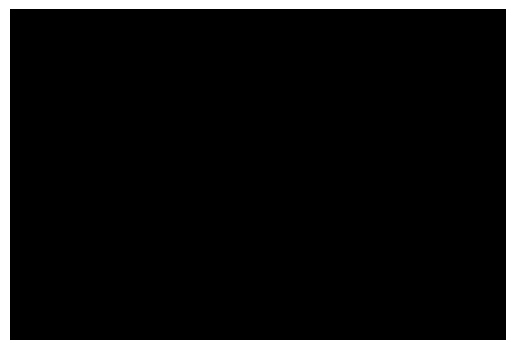

In [5]:
# Select waypoint 12 for rendering
ci = 12
origin = params['positions'][ci]  
yaw = params['rotations'][ci, 0] 
pitch = params['rotations'][ci, 1] 

# Render the scene from this viewpoint
colormap, depthmap = render_scene(origin, yaw, pitch)

# Display the rendered image
print(f"Rendered view from waypoint {ci}:")
print(f"Camera position: ({origin[0]:.2f}, {origin[1]:.2f}, {origin[2]:.2f})")
print(f"Camera orientation: Yaw={yaw:.1f}°, Pitch={pitch:.1f}°")
show2d([colormap], dpi=100)

The rendered image shows:
- What the UAV would capture at this position
- The quality of coverage for this viewpoint
- Whether important features are visible


## 3D Scene Visualization with Camera Waypoints

Finally, we create a comprehensive visualization combining the 3D scene geometry with all camera waypoints and the planned route.


### Load and Prepare the Scene Mesh

In [6]:
# Load the scene mesh
dataset_path = Path(config['dataset_path'])
scene_name = config['scene_name']
mesh_dir = 'MeshLR'
mesh_path = dataset_path / scene_name / mesh_dir / f"{scene_name}.ply"
msh = o3d.io.read_triangle_mesh(str(mesh_path))

# Simplify mesh for interactive visualization
voxel_size = 0.2
simplified_mesh = msh.simplify_vertex_clustering(
    voxel_size=voxel_size,
    contraction=o3d.geometry.SimplificationContraction.Average
)

print(f"Original triangles: {len(msh.triangles)}")
print(f"Simplified triangles: {len(simplified_mesh.triangles)}")
print(f"Reduction ratio: {len(simplified_mesh.triangles)/len(msh.triangles)*100:.1f}%")

Original triangles: 6915868
Simplified triangles: 176181
Reduction ratio: 2.5%


### Create the Visualization

In [7]:
plotly_objs = []

# Extract mesh data
vertices = np.asarray(simplified_mesh.vertices)
triangles = np.asarray(simplified_mesh.triangles)

# Create mesh trace with vertex colors if available
if simplified_mesh.has_vertex_colors():
    vertex_colors = np.asarray(simplified_mesh.vertex_colors)
    vertex_color_strings = ['rgb({},{},{})'.format(
        int(c[0]*255), int(c[1]*255), int(c[2]*255)
    ) for c in vertex_colors]
    
    mesh_trace = go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1], 
        z=vertices[:, 2],
        i=triangles[:, 0],
        j=triangles[:, 1],
        k=triangles[:, 2],
        vertexcolor=vertex_color_strings,
        opacity=1.0,
        lighting=dict(
            ambient=0.7,
            diffuse=0.8,
            specular=0.1,
            roughness=0.5,
            fresnel=0.2
        ),
        lightposition=dict(x=100, y=100, z=100),
        flatshading=False,
        hoverinfo='skip',
        showscale=False,
        name='3D Mesh'
    )
    plotly_objs.append(mesh_trace)

fig = show3d_plotly(plotly_objs, ret=True)
fig.show()